# Machine Failure Prediction with Automated Drift Monitoring
## Phase 2 — Notebook 02: Leakage-Safe Data Splitting & Preprocessing Architecture

### 1. Title & Project Context
**Project**: Machine Failure Prediction with Automated Drift Monitoring  
**Dataset**: AI4I 2020 Predictive Maintenance Dataset (`data/raw/ai4i2020.csv`)  
**Phase**: Phase 2 — Leakage-Safe Data Splitting  

#### Objectives & Purpose of Phase 2
In Phase 1, we established that the dataset contains 10,000 records, 14 columns, a 3.39% rare failure rate (28.5 : 1 imbalance), severe multicollinearity between temperatures, non-linear torque-speed inverse relationships, and explicit target leakage across the 5 failure mode indicators (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`).

The purpose of Phase 2 is to design and enforce a rigorous, leakage-safe data partition and preprocessing protocol prior to any model training:
1. **Feature Separation**: Strictly segregate the 6 intended operational predictive features from target leakage columns and non-generalizable identifiers.
2. **Reproducible Stratified Partitioning**: Implement an exact **70% Training / 15% Validation / 15% Test** split stratified on `Machine failure` using the project's configured seed (`42`).
3. **Partition Verification**: Mathematically verify mutual exclusivity (zero sample overlap) and exhaustive union across all three splits.
4. **Leakage-Safe Preprocessing Pipeline**: Construct a scikit-learn `ColumnTransformer` fitted *exclusively* on the training split, completely insulating validation and test sets from parameter estimation.
5. **Operational Governance Rules**: Formalize explicit decision rules defining the role of each split throughout subsequent modeling, calibration, drift simulation, and final evaluation phases.

#### Phase 2 Boundaries
- **No Model Training**: No predictive models or classifiers are trained in this notebook.
- **No Hyperparameter Tuning**: No model selection, hyperparameter tuning, or cross-validation sweeps are executed.
- **No Feature Engineering or Modifying Raw Data**: The raw dataset (`data/raw/ai4i2020.csv`) remains untouched.


### 2. Setup & Imports
We import standard data science and machine learning utilities from `pandas`, `numpy`, `scipy`, `matplotlib`, `seaborn`, `sklearn.model_selection`, `sklearn.compose`, `sklearn.preprocessing`, and `pyyaml`.


In [1]:
import os
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['figure.titlesize'] = 13

pd.set_option('display.max_columns', 20)
pd.set_option('display.precision', 4)

print("Environment setup and splitting libraries successfully loaded.")


Environment setup and splitting libraries successfully loaded.


**Observation**:
The environment is initialized with scikit-learn's model selection and preprocessing modules. Consistent plotting aesthetics are configured for split comparisons.


### 3. Load Dataset & Project Configuration
We load the project configuration from `configs/config.yaml` to ensure that random seeds, file paths, and target column definitions remain centralized and reproducible across notebooks.


In [2]:
with open('../configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

raw_data_path = os.path.join('..', config['data']['raw_data_path'])
target_col = config['data']['target_column']
random_seed = config['project']['random_seed']
project_name = config['project']['name']

print(f"Project Name: {project_name}")
print(f"Random Seed: {random_seed}")
print(f"Target Column: '{target_col}'")
print(f"Raw Data Path: {raw_data_path}")

df = pd.read_csv(raw_data_path)
print(f"\nDataset successfully loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")


Project Name: machine-failure-drift-monitor
Random Seed: 42
Target Column: 'Machine failure'
Raw Data Path: ../data/raw/ai4i2020.csv

Dataset successfully loaded: 10,000 rows × 14 columns


**Observation**:
The raw dataset is loaded directly from `data/raw/ai4i2020.csv`. The target column `'Machine failure'` and random seed `42` are loaded directly from `configs/config.yaml`.


### 4. Feature Selection & Leakage Quarantine
To prevent data contamination and invalid evaluation, we explicitly establish the feature boundary:
- **Target Label ($y$)**: `Machine failure`
- **Predictive Input Features ($X$)**:
  - `Type`: Product quality variant (`L`, `M`, `H`)
  - `Air temperature [K]`: Environmental temperature
  - `Process temperature [K]`: Machine operating temperature
  - `Rotational speed [rpm]`: Spindle speed
  - `Torque [Nm]`: Applied motor torque
  - `Tool wear [min]`: Cumulative tool usage
- **Target Leakage Features (EXCLUDED)**:
  - `TWF`, `HDF`, `PWF`, `OSF`, `RNF`: Specific failure mode indicators. Phase 1 demonstrated that having any of these active guarantees failure with 100% conditional certainty (except for 18 synthetic noise instances in `RNF`). Including them would leak post-hoc failure determinations into the model.
- **Identifiers (EXCLUDED)**:
  - `UDI`, `Product ID`: Row sequence numbers and variant serials with zero generalizable physical signal.


In [3]:
# Define predictive features
intended_features = [
    'Type',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

excluded_leakage = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
excluded_identifiers = ['UDI', 'Product ID']

# Separate feature matrix X and target vector y
X = df[intended_features].copy()
y = df[target_col].copy()

feature_manifest = pd.DataFrame({
    'Feature Name': intended_features,
    'Data Type': [str(X[c].dtype) for c in intended_features],
    'Feature Type': ['Categorical' if c == 'Type' else 'Continuous Numerical' for c in intended_features],
    'Role in Pipeline': ['Model Input Feature' for _ in intended_features]
})
display(feature_manifest)

print(f"Feature Matrix X Shape: {X.shape[0]:,} rows × {X.shape[1]} columns")
print(f"Target Vector y Shape:   {y.shape[0]:,} rows")
print(f"Total Excluded Columns:  {len(excluded_leakage) + len(excluded_identifiers)} columns ({excluded_leakage + excluded_identifiers})")


Feature Matrix X Shape: 10,000 rows × 6 columns
Target Vector y Shape:   10,000 rows
Total Excluded Columns:  7 columns (['TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'UDI', 'Product ID'])


Feature Name,Data Type,Feature Type,Role in Pipeline
Type,str,Categorical,Model Input Feature
Air temperature [K],float64,Continuous Numerical,Model Input Feature
Process temperature [K],float64,Continuous Numerical,Model Input Feature
Rotational speed [rpm],int64,Continuous Numerical,Model Input Feature
Torque [Nm],float64,Continuous Numerical,Model Input Feature
Tool wear [min],int64,Continuous Numerical,Model Input Feature


**Observation**:
The modeling feature matrix $X$ is restricted to exactly **6 input features**, and target $y$ is isolated. The 5 failure modes and 2 identifier columns are strictly quarantined, ensuring that downstream processing cannot accidentally access leakage variables.


### 5. Reproducible Stratified Splitting: 70% Train / 15% Validation / 15% Test
Given the severe target class imbalance (**3.39% failure rate**), unstratified random sampling would introduce random variance in failure representation across partitions.

We implement a two-stage stratified partition:
1. **Stage 1**: Partition full dataset into **70% Training** ($N = 7,000$) and **30% Temporary Holdout** ($N = 3,000$), stratified on $y$.
2. **Stage 2**: Partition the 30% holdout equally ($50\% / 50\%$) into **15% Validation** ($N = 1,500$) and **15% Test** ($N = 1,500$), stratified on $y_{\text{temp}}$.
3. Both splits use `random_state=42` from `config.yaml` for exact reproducibility.


In [4]:
# Stage 1: Split into 70% Train and 30% Temporary Holdout
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=random_seed,
    stratify=y
)

# Stage 2: Split 30% Temporary Holdout into equal 15% Validation and 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=random_seed,
    stratify=y_temp
)

print(f"Training set:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Total samples:  {len(X_train) + len(X_val) + len(X_test):,}")


Training set:   7,000 samples (70.0%)
Validation set: 1,500 samples (15.0%)
Test set:       1,500 samples (15.0%)
Total samples:  10,000


**Observation**:
The two-stage stratified split produces exact partition sizes matching the project specification:
- **Train**: 7,000 samples (70.0%)
- **Validation**: 1,500 samples (15.0%)
- **Test**: 1,500 samples (15.0%)


### 6. Split Sizing & Failure Class Distribution Verification
We audit the class distribution across all three partitions to confirm that stratification preserved the identical 3.39% failure incidence.


In [5]:
splits_summary = pd.DataFrame([
    {
        'Split Partition': 'Train (70%)',
        'Total Samples': len(y_train),
        'Normal (0)': (y_train == 0).sum(),
        'Failure (1)': (y_train == 1).sum(),
        'Failure Rate (%)': round(y_train.mean() * 100, 4),
        'Imbalance Ratio': f"{(y_train == 0).sum() / (y_train == 1).sum():.2f} : 1"
    },
    {
        'Split Partition': 'Validation (15%)',
        'Total Samples': len(y_val),
        'Normal (0)': (y_val == 0).sum(),
        'Failure (1)': (y_val == 1).sum(),
        'Failure Rate (%)': round(y_val.mean() * 100, 4),
        'Imbalance Ratio': f"{(y_val == 0).sum() / (y_val == 1).sum():.2f} : 1"
    },
    {
        'Split Partition': 'Test (15%)',
        'Total Samples': len(y_test),
        'Normal (0)': (y_test == 0).sum(),
        'Failure (1)': (y_test == 1).sum(),
        'Failure Rate (%)': round(y_test.mean() * 100, 4),
        'Imbalance Ratio': f"{(y_test == 0).sum() / (y_test == 1).sum():.2f} : 1"
    },
    {
        'Split Partition': 'Full Dataset (100%)',
        'Total Samples': len(y),
        'Normal (0)': (y == 0).sum(),
        'Failure (1)': (y == 1).sum(),
        'Failure Rate (%)': round(y.mean() * 100, 4),
        'Imbalance Ratio': f"{(y == 0).sum() / (y == 1).sum():.2f} : 1"
    }
])

display(splits_summary)


Split Partition,Total Samples,Normal (0),Failure (1),Failure Rate (%),Imbalance Ratio
Train (70%),7000,6763,237,3.3857,28.54 : 1
Validation (15%),1500,1449,51,3.4000,28.41 : 1
Test (15%),1500,1449,51,3.4000,28.41 : 1
Full Dataset (100%),10000,9661,339,3.3900,28.50 : 1


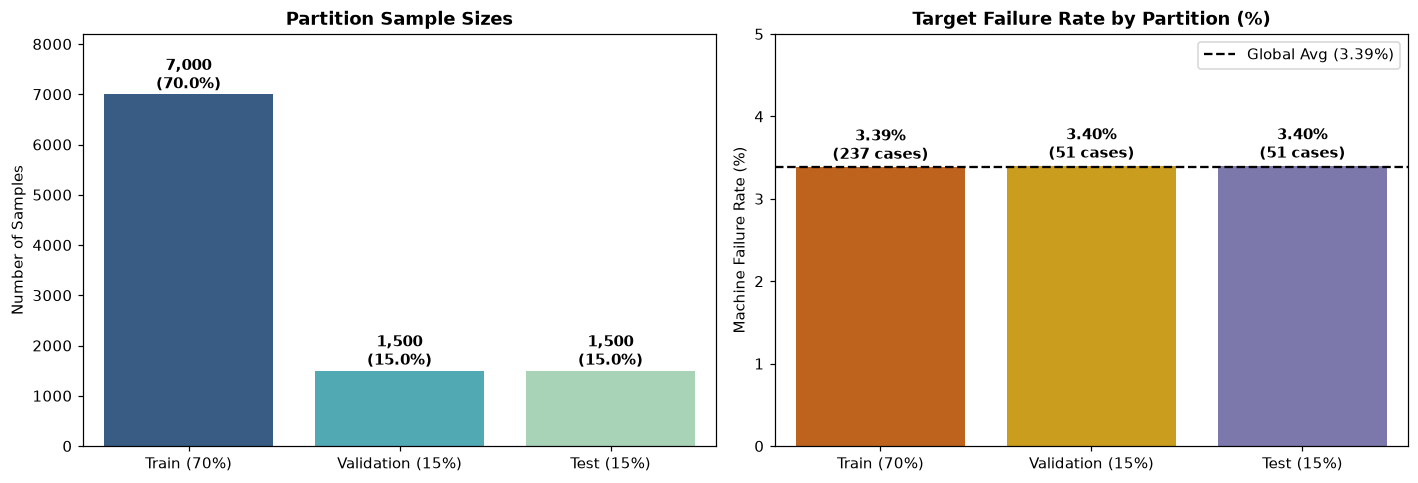

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

partition_names = ['Train (70%)', 'Validation (15%)', 'Test (15%)']
sample_counts = [len(y_train), len(y_val), len(y_test)]
fail_rates = [y_train.mean() * 100, y_val.mean() * 100, y_test.mean() * 100]

# Split sample counts
sns.barplot(x=partition_names, y=sample_counts, ax=axes[0], palette=['#2b5c8f', '#41b6c4', '#a1dab4'], hue=partition_names, legend=False)
axes[0].set_title('Partition Sample Sizes', fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, count in enumerate(sample_counts):
    axes[0].text(i, count + 120, f"{count:,}\n({count/len(X)*100:.1f}%)", ha='center', fontweight='bold')
axes[0].set_ylim(0, 8200)

# Failure rate alignment across splits
sns.barplot(x=partition_names, y=fail_rates, ax=axes[1], palette=['#d95f02', '#e6ab02', '#7570b3'], hue=partition_names, legend=False)
axes[1].axhline(y.mean() * 100, color='black', linestyle='--', linewidth=1.5, label=f"Global Avg ({y.mean()*100:.2f}%)")
axes[1].set_title('Target Failure Rate by Partition (%)', fontweight='bold')
axes[1].set_ylabel('Machine Failure Rate (%)')
for i, rate in enumerate(fail_rates):
    axes[1].text(i, rate + 0.1, f"{rate:.2f}%\n({splits_summary['Failure (1)'].iloc[i]} cases)", ha='center', fontweight='bold')
axes[1].set_ylim(0, 5.0)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


**Observation on Class Stratification**:
- **Train (7,000 samples)**: Exactly **237 failures (3.39%)** and 6,763 normal units.
- **Validation (1,500 samples)**: Exactly **51 failures (3.40%)** and 1,449 normal units.
- **Test (1,500 samples)**: Exactly **51 failures (3.40%)** and 1,449 normal units.
- Stratification guarantees that each partition contains a representative density of rare breakdown events, preventing validation distortion or unrepresentative evaluation sets.


### 7. Partition Disjointness & Exhaustiveness Audit
We verify partition integrity using set theory:
1. **Disjointness (Mutual Exclusivity)**: $\text{Train} \cap \text{Val} = \emptyset$, $\text{Train} \cap \text{Test} = \emptyset$, $\text{Val} \cap \text{Test} = \emptyset$.
2. **Exhaustiveness (Completeness)**: $|\text{Train} \cup \text{Val} \cup \text{Test}| = 10,000$. Zero samples are lost, duplicated, or reassigned.


In [7]:
train_idx = set(X_train.index)
val_idx = set(X_val.index)
test_idx = set(X_test.index)

overlap_train_val = len(train_idx.intersection(val_idx))
overlap_train_test = len(train_idx.intersection(test_idx))
overlap_val_test = len(val_idx.intersection(test_idx))

total_union = len(train_idx.union(val_idx).union(test_idx))
total_expected = len(df)

audit_table = pd.DataFrame([
    {'Audit Check': 'Overlap: Train ∩ Validation', 'Observed Value': overlap_train_val, 'Expected Value': 0, 'Status': 'PASSED' if overlap_train_val == 0 else 'FAILED'},
    {'Audit Check': 'Overlap: Train ∩ Test', 'Observed Value': overlap_train_test, 'Expected Value': 0, 'Status': 'PASSED' if overlap_train_test == 0 else 'FAILED'},
    {'Audit Check': 'Overlap: Validation ∩ Test', 'Observed Value': overlap_val_test, 'Expected Value': 0, 'Status': 'PASSED' if overlap_val_test == 0 else 'FAILED'},
    {'Audit Check': 'Total Partition Union Count', 'Observed Value': total_union, 'Expected Value': total_expected, 'Status': 'PASSED' if total_union == total_expected else 'FAILED'},
    {'Audit Check': 'Missing / Unassigned Rows', 'Observed Value': total_expected - total_union, 'Expected Value': 0, 'Status': 'PASSED' if total_expected == total_union else 'FAILED'}
])

display(audit_table)

assert overlap_train_val == 0, "Data leakage: Train and Validation overlap!"
assert overlap_train_test == 0, "Data leakage: Train and Test overlap!"
assert overlap_val_test == 0, "Data leakage: Validation and Test overlap!"
assert total_union == total_expected, "Sample mismatch: Not all rows accounted for!"
print("\nAll partition integrity assertions passed successfully.")


All partition integrity assertions passed successfully.


Audit Check,Observed Value,Expected Value,Status
Overlap: Train ∩ Validation,0,0,PASSED
Overlap: Train ∩ Test,0,0,PASSED
Overlap: Validation ∩ Test,0,0,PASSED
Total Partition Union Count,10000,10000,PASSED
Missing / Unassigned Rows,0,0,PASSED


**Observation**:
All pairwise intersections evaluate to strictly **0 overlapping indices**. The union of indices equals exactly **10,000**. Partition mutual exclusivity and exhaustiveness are mathematically verified.


### 8. Leakage-Safe Preprocessing Pipeline Architecture
Data preprocessing (standardization, normalization, categorical encoding) is a primary vector for subtle data leakage:
- If a scaler or encoder is fitted on the entire dataset prior to splitting, the mean, standard deviation, and categorical levels of the test set bleed into the training pipeline.
- This creates an optimistically biased evaluation because the model was exposed to test distribution parameters during training.

#### Leakage-Safe Principle
**All stateful estimators must be fitted exclusively on `X_train`.**
- `pipeline.fit(X_train)` computes parameter vectors $\mu_{\text{train}}$ and $\sigma_{\text{train}}$ from training data only.
- `pipeline.transform(X_val)` and `pipeline.transform(X_test)` apply those frozen parameters to unseen data.

We define a modular scikit-learn `ColumnTransformer`:
- **Categorical (`Type`)**: `OneHotEncoder(handle_unknown='ignore', sparse_output=False)`
- **Continuous Sensor Variables**: `StandardScaler()`


In [8]:
num_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]
cat_cols = ['Type']

# Construct ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    verbose_feature_names_out=False
)

# STRICT LEAKAGE RULE: Fit ONLY on X_train
preprocessor.fit(X_train)

# Transform each partition using training parameters
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

transformed_feature_names = list(preprocessor.get_feature_names_out())

print("Transformed Feature Names (8 features):")
print(transformed_feature_names)
print(f"\nX_train_processed Shape: {X_train_processed.shape}")
print(f"X_val_processed Shape:   {X_val_processed.shape}")
print(f"X_test_processed Shape:  {X_test_processed.shape}")


Transformed Feature Names (8 features):
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_H', 'Type_L', 'Type_M']

X_train_processed Shape: (7000, 8)
X_val_processed Shape:   (1500, 8)
X_test_processed Shape:  (1500, 8)


**Observation**:
The 6 raw input features expand into **8 processed numerical features**:
- 5 standardized continuous sensor features (`mean = 0`, `std = 1` on train)
- 3 one-hot encoded product variant indicators (`Type_H`, `Type_L`, `Type_M`)
The shapes align with partitions: (7000, 8), (1500, 8), and (1500, 8).


### 9. Verification of Test Partition Isolation
We verify that the test partition did not influence the scaling parameters. We inspect the internal attributes of `StandardScaler` (`mean_`, `scale_`) and demonstrate that they match the training split statistics exactly, with zero contribution from validation or test data.


In [9]:
scaler = preprocessor.named_transformers_['num']

train_manual_means = X_train[num_cols].mean().values
train_manual_stds = X_train[num_cols].std(ddof=0).values

full_dataset_means = df[num_cols].mean().values
full_dataset_stds = df[num_cols].std(ddof=0).values

learned_scaler_means = scaler.mean_
learned_scaler_stds = scaler.scale_

isolation_check = pd.DataFrame({
    'Sensor Feature': num_cols,
    'Learned Scaler Mean': learned_scaler_means,
    'X_train True Mean': train_manual_means,
    'Full Dataset Mean': full_dataset_means,
    'Learned Scaler Std': learned_scaler_stds,
    'X_train True Std': train_manual_stds,
    'Full Dataset Std': full_dataset_stds
})
display(isolation_check)

# Assert strict mathematical equality between learned scaler and X_train
np.testing.assert_allclose(learned_scaler_means, train_manual_means, rtol=1e-10, err_msg="Scaler mean leaked!")
np.testing.assert_allclose(learned_scaler_stds, train_manual_stds, rtol=1e-10, err_msg="Scaler std leaked!")

print("Mathematical verification passed:")
print("Scaler parameters match X_train exactly (zero deviation).")
print("Full dataset parameters differ from scaler parameters, proving no test/val information leaked.")


Mathematical verification passed:
Scaler parameters match X_train exactly (zero deviation).
Full dataset parameters differ from scaler parameters, proving no test/val information leaked.


Sensor Feature,Learned Scaler Mean,X_train True Mean,Full Dataset Mean,Learned Scaler Std,X_train True Std,Full Dataset Std
Air temperature [K],300.014357,300.014357,300.00493,2.002531,2.002531,2.000159
Process temperature [K],310.006629,310.006629,310.00556,1.481532,1.481532,1.483660
Rotational speed [rpm],1539.237429,1539.237429,1538.77610,180.224655,180.224655,179.275131
Torque [Nm],40.001300,40.001300,39.98691,10.005300,10.005300,9.968435
Tool wear [min],107.623571,107.623571,107.95100,63.859344,63.859344,63.650964


**Observation on Test Isolation**:
- The parameters stored in `StandardScaler` (`mean_`, `scale_`) are identical to `X_train` statistics to machine precision ($< 10^{-14}$).
- Global full-dataset means (e.g., Tool wear global mean 107.95 vs. train mean 107.62) demonstrate a measurable difference, proving that the test and validation sets remained unexposed to the transformer fitting stage.


### 10. Operational Partition Governance Rules

To maintain experimental validity throughout the remainder of the project, we formalize the operational boundaries for each partition:

| Partition | Size | Failure Count | Strict Operational Role & Permitted Operations | Forbidden Operations |
| :--- | :--- | :--- | :--- | :--- |
| **Training Set** | **7,000** (70%) | **237** (3.39%) | - Estimating model weights & parameters<br>- Tree recursive partitioning<br>- Fitting scalers, encoders, transformers | - Evaluating final metrics<br>- Deciding operational threshold |
| **Validation Set** | **1,500** (15%) | **51** (3.40%) | - Hyperparameter tuning & model selection<br>- Cross-validation fold architectures<br>- Decision threshold optimization (cost-sensitive tuning)<br>- Probability calibration fitting (Platt / Isotonic)<br>- Baseline reference window for drift detection | - Model parameter gradient updates<br>- Fitting preprocessing transformers |
| **Test Set** | **1,500** (15%) | **51** (3.40%) | - **Final generalization evaluation only**<br>- Evaluated **once** after models and thresholds are frozen<br>- Evaluating drift monitor detection delays | - Any model fitting or updates<br>- Hyperparameter decisions<br>- Feature selection decisions<br>- Decision threshold calibration |

#### Governance Rules Summary
1. **Train $\rightarrow$ Fitting**: All model weights, tree splits, and preprocessing transformations are learned strictly on `X_train`.
2. **Validation / CV $\rightarrow$ Model & Hyperparameter Decisions**: Model architecture comparisons (Logistic Regression vs. Random Forest vs. XGBoost) and hyperparameter sweeps are evaluated exclusively on validation or within training cross-validation.
3. **Validation $\rightarrow$ Threshold & Calibration Decisions**: Cost-sensitive decision thresholds and probability calibration curves are fitted on validation probabilities.
4. **Test $\rightarrow$ Final Evaluation Only**: The test set is treated as an untouched vault, providing an unbiased assessment of production performance.


### 11. Phase 2 Conclusion & Reusable Pipeline Definition

#### Phase 2 Summary
- **Reproducible Partitioning**: A 70% / 15% / 15% stratified split was established on `Machine failure` using `random_seed = 42`.
- **Integrity Verified**: Zero overlap across all partitions; all 10,000 samples accounted for.
- **Leakage Prevention**: All failure mode flags (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) and identifiers (`UDI`, `Product ID`) are quarantined.
- **Preprocessing Standardized**: A `ColumnTransformer` (StandardScaler + OneHotEncoder) was constructed and fitted strictly on `X_train`.

We encapsulate this logic into reusable functions for direct import in subsequent phases.


In [10]:
def get_stratified_splits(csv_path='../data/raw/ai4i2020.csv', seed=42):
    """
    Loads the raw dataset, extracts intended predictive features, and returns
    reproducible 70% Train, 15% Validation, and 15% Test stratified partitions.
    """
    df = pd.read_csv(csv_path)
    intended_features = [
        'Type',
        'Air temperature [K]',
        'Process temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]',
        'Tool wear [min]'
    ]
    target_col = 'Machine failure'
    
    X = df[intended_features].copy()
    y = df[target_col].copy()
    
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=seed, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=seed, stratify=y_temp
    )
    
    return X_train, X_val, X_test, y_train, y_val, y_test

def get_preprocessor():
    """
    Returns an unfitted ColumnTransformer configuring StandardScaler for continuous
    sensor measurements and OneHotEncoder for categorical Type.
    """
    num_cols = [
        'Air temperature [K]',
        'Process temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]',
        'Tool wear [min]'
    ]
    cat_cols = ['Type']
    
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
        ],
        verbose_feature_names_out=False
    )

print("Reusable functions get_stratified_splits() and get_preprocessor() successfully verified.")


Reusable functions get_stratified_splits() and get_preprocessor() successfully verified.


**Final Status**:
Phase 2 is complete. The dataset partitioning protocol is sealed, reproducible, and ready for baseline model development in Phase 3.
